In [8]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt


# Загружаем изображение и преобразуем его в чёрно-белое
img = Image.open("image-3.png").convert('L')
img = img.resize((28, 28))

pixels = np.array(img) / 255.0
inputs = pixels.flatten()

np.random.seed(42)

# Создайте переменные weights и bias здесь
weights = np.random.randn(len(inputs))   # Ваш код здесь
bias = np.random.randn()      # Ваш код здесь


print("Количество входов:", len(inputs))
print("Форма weights:", weights.shape)
print("Пример первых 5 весов:", weights[:5])
print("Bias:", bias) 

Количество входов: 784
Форма weights: (784,)
Пример первых 5 весов: [ 0.49671415 -0.1382643   0.64768854  1.52302986 -0.23415337]
Bias: 0.5597904479310398


In [25]:
img = Image.open("image-3.png").convert('L').resize((28, 28))
pixels = np.array(img) / 255.0
inputs = pixels.flatten()

np.random.seed(42)
weights = np.random.randn(len(inputs))
bias = np.random.randn()

# Напишите код функции ReLU - верните «обрезанное» значение — минимум 0, максимум x.
# Ваш код здесь
def relu(x):
    return np.maximum(0,x)

# Допишите код функции нейрона.
def neuron(inputs, weights, bias):    
    # Вычислите total = сумма + bias
    total = np.dot(inputs, weights) + bias
    # Примените ReLU
    output = relu(total)
    return output

output = neuron(inputs, weights, bias)
print("Выход нейрона:", output) 

Выход нейрона: 0.0


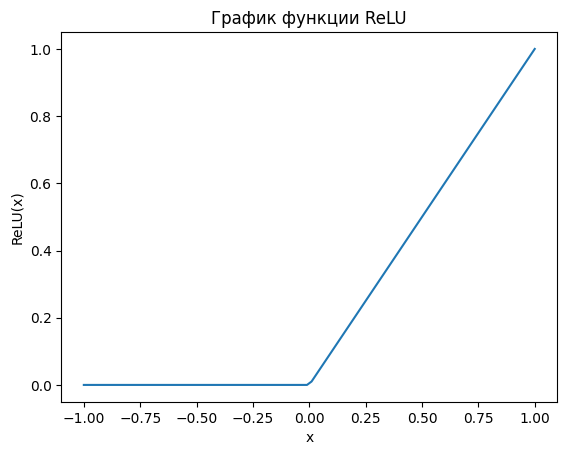

In [26]:
def relu(x):
    return np.maximum(0,x)

x = np.linspace(-1, 1, 100)
y = relu(x)  # применяем вашу функцию

plt.plot(x, y)
plt.title("График функции ReLU")
plt.xlabel("x")
plt.ylabel("ReLU(x)")
plt.show()

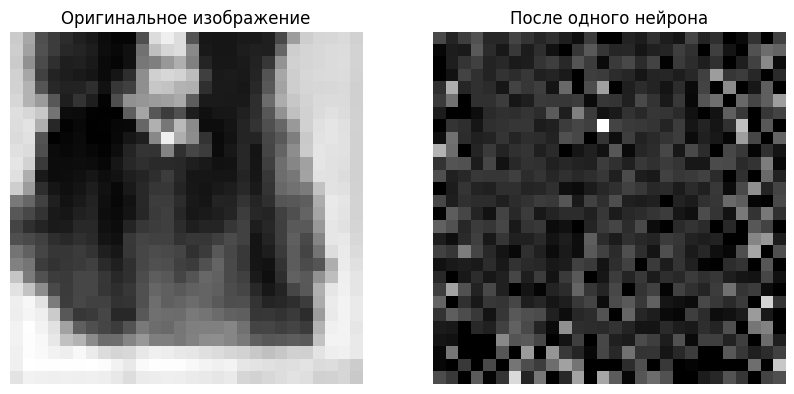

In [30]:
np.random.seed(42) 
img = Image.open("data/image-3.png").convert('L')
img = img.resize((28, 28))
pixels = np.array(img) / 255.0
weights = np.random.randn(28 * 28)
bias = np.random.randn()

def relu(x): 
    return np.maximum(0, x)

# Допишите функцию pixelwise_neuron: которая берёт pixels, превращает в плоский вектор, затем поэлементно умножает 
# на weights и прибавляет bias, применяет вашу функцию relu ко всем элементам, восстанавливает форму (28×28) и возвращает результат.
def pixelwise_neuron(pixels, weights, bias):
    flat = pixels.flatten()
    activated = relu(flat * weights + bias)
    return activated.reshape(pixels.shape)


# Примените только что написанную функцию к изображению
processed = pixelwise_neuron(pixels, weights, bias)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(pixels, cmap='gray')
axs[0].set_title('Оригинальное изображение')
axs[0].axis('off')

axs[1].imshow(processed, cmap='gray')
axs[1].set_title('После одного нейрона')
axs[1].axis('off')

plt.show() 

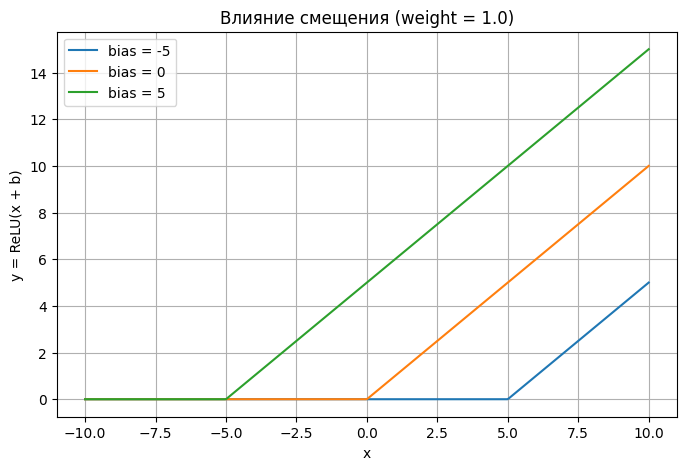

In [35]:
import numpy as np
import matplotlib.pyplot as plt

def relu(x):
    return np.maximum(0,x)
    # Допишите код как реализацию функции ReLU

def neuron(x, weight, bias):    
    return relu(x * weight + bias)
    # Допишите код как реализацию нейрона с весами и смещением

x = np.linspace(-10, 10, 400)
weight = 1.0
biases = [-5, 0, 5]

plt.figure(figsize=(8, 5))
for b in biases:
    y = neuron(x, weight, b)
    plt.plot(x, y, label=f"bias = {b}")

plt.title("Влияние смещения (weight = 1.0)")
plt.xlabel("x")
plt.ylabel("y = ReLU(x + b)")
plt.legend()
plt.grid(True)
plt.show() 

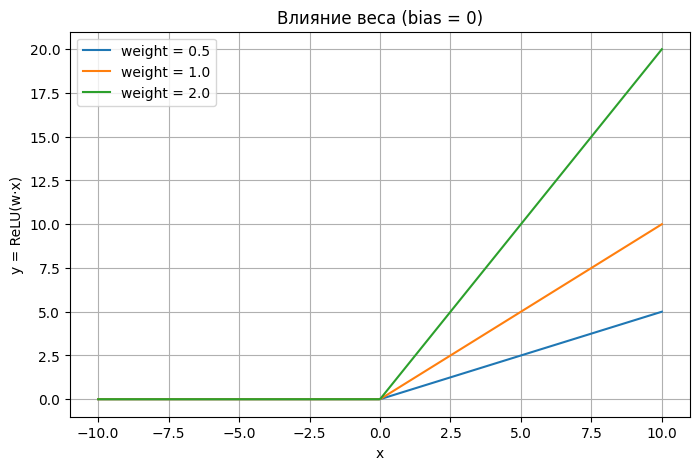

In [36]:
# диапазон входов
x = np.linspace(-10, 10, 400)
bias = 0
weights = [0.5, 1.0, 2.0]

plt.figure(figsize=(8, 5))
for w in weights:
    y = neuron(x, w, bias)
    plt.plot(x, y, label=f"weight = {w}")

plt.title("Влияние веса (bias = 0)")
plt.xlabel("x")
plt.ylabel("y = ReLU(w·x)")
plt.legend()
plt.grid(True)
plt.show() 

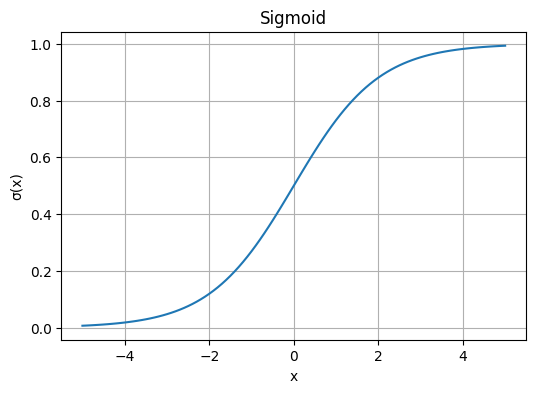

In [37]:
import math

def sigmoid(x: float) -> float:
    return 1 / (1 + math.exp(-x))

x_vals = [i * 0.1 for i in range(-50, 51)] # Генерируем значения от -5 до 5 с шагом 0.1
y_vals = [sigmoid(x) for x in x_vals] # Применяем функцию sigmoid к каждому значению

plt.figure(figsize=(6,4))
plt.plot(x_vals, y_vals)
plt.title("Sigmoid")
plt.xlabel("x")
plt.ylabel("σ(x)")
plt.grid(True)
plt.show() 

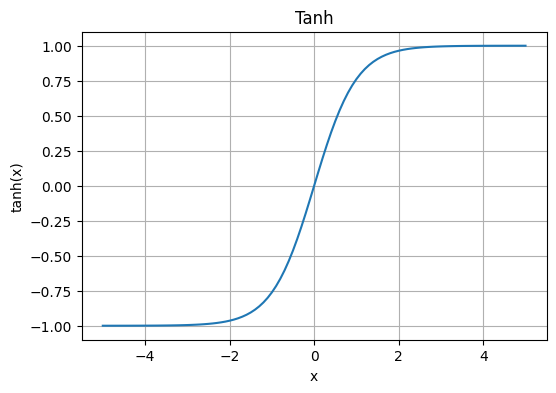

In [38]:
def tanh(x: float) -> float:
    return math.tanh(x)

x_vals = [i * 0.1 for i in range(-50, 51)]
y_vals = [tanh(x) for x in x_vals]
plt.figure(figsize=(6,4))
plt.plot(x_vals, y_vals)
plt.title("Tanh")
plt.xlabel("x")
plt.ylabel("tanh(x)")
plt.grid(True)
plt.show() 

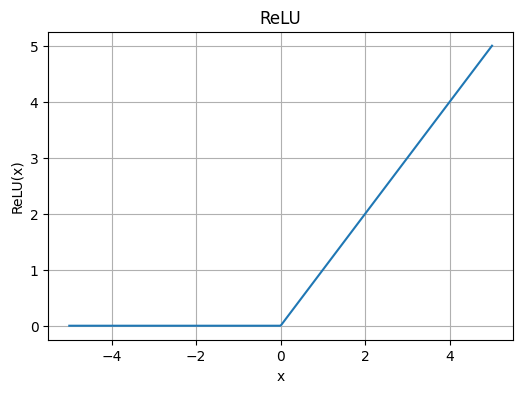

In [39]:
def relu(x):
    return np.maximum(0, x)

x_vals = np.linspace(-5, 5, 400)
y_vals = relu(x_vals)
plt.figure(figsize=(6,4))
plt.plot(x_vals, y_vals)
plt.title("ReLU")
plt.xlabel("x")
plt.ylabel("ReLU(x)")
plt.grid(True)
plt.show() 

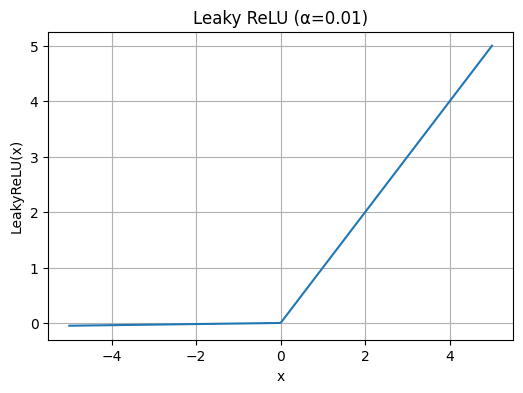

In [40]:
def leaky_relu(x, alpha=0.01):
    return np.where(x >= 0, x, alpha * x)

x_vals = np.linspace(-5, 5, 400)
y_vals = leaky_relu(x_vals)
plt.figure(figsize=(6,4))
plt.plot(x_vals, y_vals)
plt.title("Leaky ReLU (α=0.01)")
plt.xlabel("x")
plt.ylabel("LeakyReLU(x)")
plt.grid(True)
plt.show() 

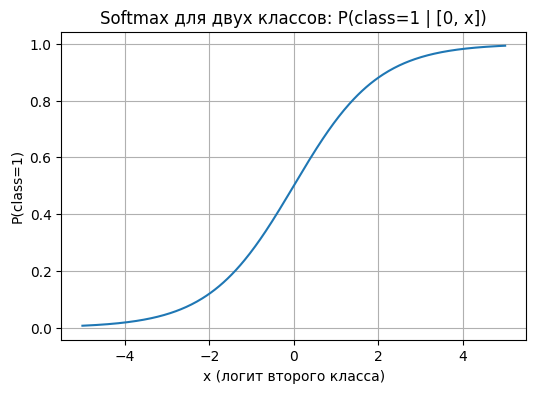

In [41]:
def softmax(z):
    # 1) для стабильности вычитаем максимум
    e_z = np.exp(z - np.max(z))
    # 2) нормируем экспоненты, чтобы сумма = 1
    return e_z / e_z.sum()

# диапазон значений второго логита
x_vals = np.linspace(-5, 5, 400)
# для каждого x считаем только P(class=1) в Softmax([0, x])
p1 = [softmax([0, x])[1] for x in x_vals]

plt.figure(figsize=(6,4))
plt.plot(x_vals, p1)
plt.title("Softmax для двух классов: P(class=1 | [0, x])")
plt.xlabel("x (логит второго класса)")
plt.ylabel("P(class=1)")
plt.grid(True)
plt.show() 

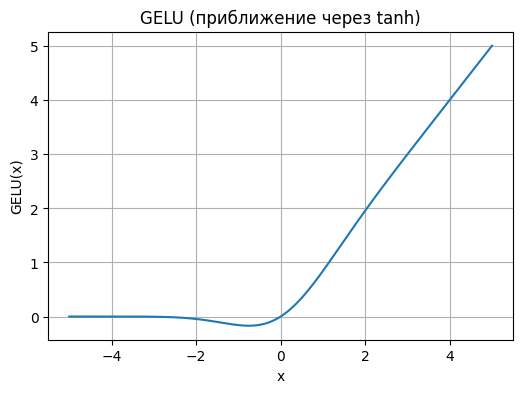

In [42]:
def gelu(x: np.ndarray) -> np.ndarray:
    # Приближение через tanh
    return 0.5 * x * (1 + np.tanh(np.sqrt(2/np.pi)*(x + 0.044715 * x**3)))

# Диапазон для визуализации
x_vals = np.linspace(-5, 5, 400)
y_vals = gelu(x_vals)

plt.figure(figsize=(6,4))
plt.plot(x_vals, y_vals)
plt.title("GELU (приближение через tanh)")
plt.xlabel("x")
plt.ylabel("GELU(x)")
plt.grid(True)
plt.show()

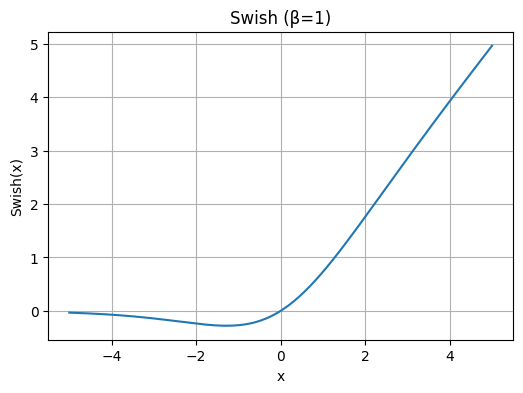

In [43]:
def sigmoid(x: np.ndarray) -> np.ndarray:
    return 1 / (1 + np.exp(-x))

def swish(x: np.ndarray, beta: float = 1.0) -> np.ndarray:
    return x * sigmoid(beta * x)

# Диапазон для визуализации
x_vals = np.linspace(-5, 5, 400)
y_vals = swish(x_vals)

plt.figure(figsize=(6,4))
plt.plot(x_vals, y_vals)
plt.title("Swish (β=1)")
plt.xlabel("x")
plt.ylabel("Swish(x)")
plt.grid(True)
plt.show() 

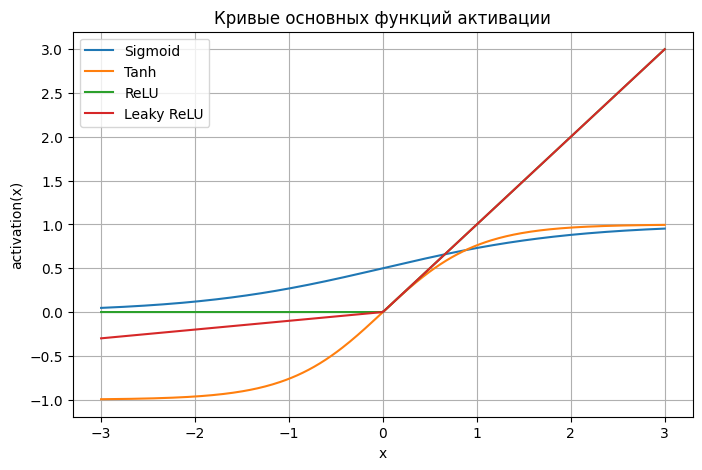

In [47]:
# 1) Входные данные
x = np.linspace(-3, 3, 300)

# 2) Реализация функций активации

def sigmoid(x: float) -> float:
    return 1 / (1 + np.exp(-x))

def tanh_act(x: float) -> float:
    return np.tanh(x)

def relu(x):
    return np.maximum(0, x)

def leaky_relu(x, alpha=0.1):
    return np.where(x >= 0, x, x * alpha)

# 3) Вычисление значений (раскомментируйте после реализации функций)
y_sig = sigmoid(x)
y_tanh = tanh_act(x)
y_relu = relu(x)
y_leaky = leaky_relu(x)

# 4) Визуализация (оставьте без изменений)
plt.figure(figsize=(8, 5))
plt.plot(x, y_sig, label='Sigmoid')
plt.plot(x, y_tanh, label='Tanh')
plt.plot(x, y_relu, label='ReLU')
plt.plot(x, y_leaky, label='Leaky ReLU')
plt.title('Кривые основных функций активации')
plt.xlabel('x')
plt.ylabel('activation(x)')
plt.legend()
plt.grid(True)
plt.show() 

In [53]:
class MLP:

    def __init__(self, layer_sizes, activation='sigmoid'):
        self.layer_sizes = layer_sizes
        self.activation = activation
        self.W = []      # список матриц весов
        self.b = []      # список векторов смещений
        # Ваша задача заполнить self.W и self.b случайными параметрами
        for i in range(len(layer_sizes) - 1):
            in_dim = layer_sizes[i]
            out_dim = layer_sizes[i + 1]
            weight_matrix = np.random.randn(in_dim, out_dim) * 0.1
            bias_vector = np.zeros((1, out_dim))
            self.W.append(weight_matrix)
            self.b.append(bias_vector)

    def _sigmoid(self, Z):
        return(1 / (1 + np.exp(-Z)))

    # Допишите метод forward    
    def forward(self, X):
        A = X
        for i, (W, b) in enumerate(zip(self.W, self.b)):
            Z = A.dot(W) + b
            if i < len(self.W) - 1:
                A = self._sigmoid(Z)
            else:
                A = Z  # линейный выход для последнего слоя
        return A

# Запускаем модель
np.random.seed(42)
# Инициализируем модель с 4 слоями: 10 входов, 32 нейрона, 16 нейронов и 5 выходов
model = MLP([10, 32, 16, 5], activation='sigmoid')
# Создаём случайный входной массив размером 100 примеров по 10 признаков
X_rand = np.random.randn(100, 10)
# Запускаем прямой проход
out = model.forward(X_rand)
print("Output shape:", out.shape)
# ожидаем (100, 5) 

Output shape: (100, 5)


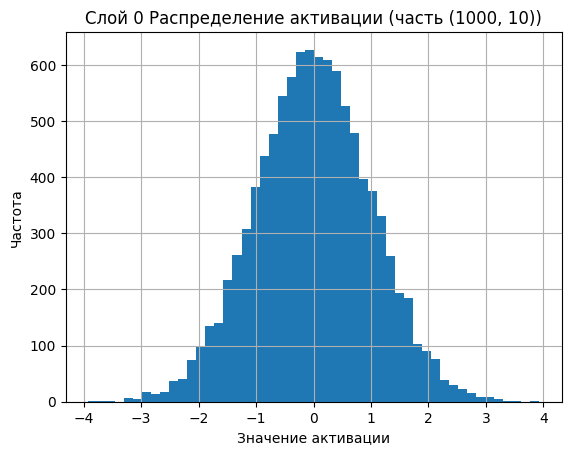

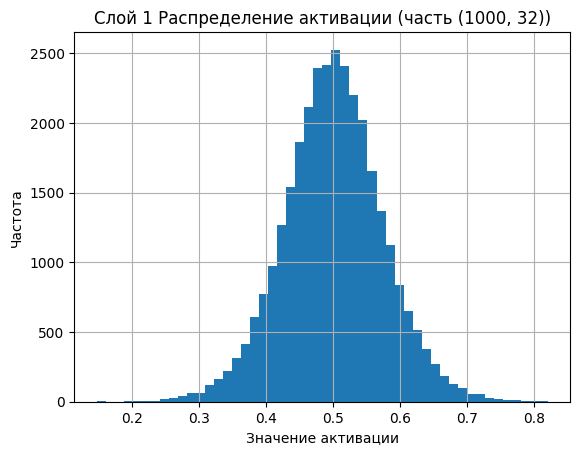

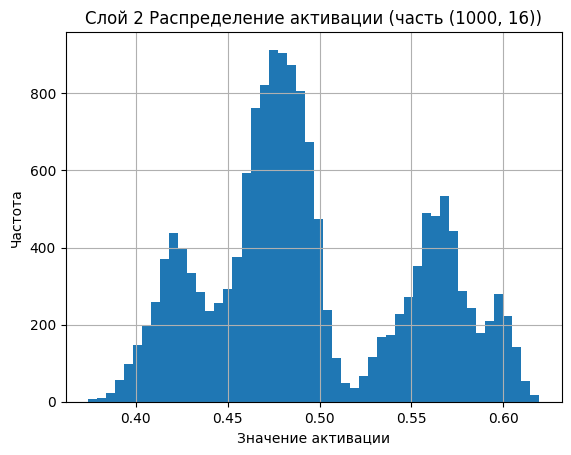

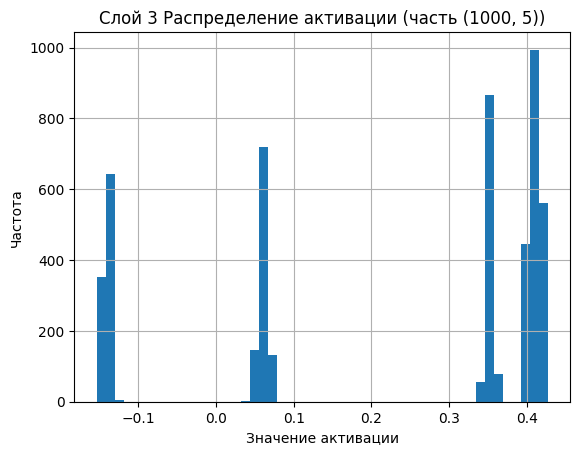

In [56]:
import matplotlib.pyplot as plt

class MLP:
    def __init__(self, layer_sizes, activation='sigmoid'):
        self.layer_sizes = layer_sizes
        self.activation = activation
        self.W = []
        self.b = []
        for i in range(len(layer_sizes) - 1):
            in_dim = layer_sizes[i]
            out_dim = layer_sizes[i + 1]
            weight_matrix = np.random.randn(in_dim, out_dim) * 0.1
            bias_vector = np.zeros((1, out_dim))
            self.W.append(weight_matrix)
            self.b.append(bias_vector)

    def _sigmoid(self, Z):
        return 1 / (1 + np.exp(-Z))

    def forward_with_activations(self, X):
        activations = [X]
        A = X
        for i, (W, b) in enumerate(zip(self.W, self.b)):
            Z = A.dot(W) + b
            if i < len(self.W) - 1:
                A = self._sigmoid(Z)
            else:
                A = Z
            activations.append(A)
        return activations

# Инициализируем модель с 4 слоями: 10 входов, 32 нейрон, 16 нейронов и 5 выходов
np.random.seed(42)
model = MLP([10, 32, 16, 5], activation='sigmoid')
X_rand = np.random.randn(1000, 10)

# Соберем активации
acts = model.forward_with_activations(X_rand)

# Отобразим активации каждого слоя
for idx, A in enumerate(acts):
    plt.figure()
    plt.hist(A.flatten(), bins=50)
    plt.title(f'Слой {idx} Распределение активации (часть {A.shape})')
    plt.xlabel('Значение активации')
    plt.ylabel('Частота')
    plt.grid(True)
    plt.show()

In [1]:
import numpy as np

class MLP:
    def __init__(self, layer_sizes, activation='sigmoid'):
        self.layer_sizes = layer_sizes
        self.activation = activation
        self.W, self.b = [], []
        # сюда будем складывать Z и A
        self.Z_list, self.A_list = [], []

        for i in range(len(layer_sizes) - 1):
            in_dim, out_dim = layer_sizes[i], layer_sizes[i + 1]
            self.W.append(np.random.randn(in_dim, out_dim) * 0.1)
            self.b.append(np.zeros((1, out_dim)))

    def _sigmoid(self, Z):
        return 1 / (1 + np.exp(-Z))

    # Напишите новый метод _relu
    def _relu(self, Z):
        return np.maximum(0, Z) 

    def forward(self, X):
        # очищаем списки перед новым вызовом
        self.Z_list, self.A_list = [], []
        A = X
        # сохраните инициализацию входного слоя в A_list
        self.A_list.append(A)

        for i, (W, b) in enumerate(zip(self.W, self.b)):
            # сохраняем линейную часть Z в Z_list
            Z = A.dot(W) + b
            self.Z_list.append(Z)

            if i < len(self.W) - 1:
                if self.activation == 'sigmoid':
                    A = self._sigmoid(Z)
                elif self.activation == 'relu':
                    A = self._relu(Z)
                else:
                    raise ValueError(f"Unknown activation {self.activation}")
            else:
                A = Z

            # сохраните активацию выходного слоя слоя в A_list
            self.A_list.append(A)

        return A 

In [2]:
class MLP:
    def __init__(self, layer_sizes, activation='sigmoid'):
        self.layer_sizes = layer_sizes
        self.activation = activation
        self.W, self.b = [], []
        # сюда будем складывать Z и A
        self.Z_list, self.A_list = [], []

        for i in range(len(layer_sizes) - 1):
            in_dim, out_dim = layer_sizes[i], layer_sizes[i + 1]
            self.W.append(np.random.randn(in_dim, out_dim) * 0.1)
            self.b.append(np.zeros((1, out_dim)))

    def _sigmoid(self, Z):
        return 1 / (1 + np.exp(-Z))

    def _relu(self, Z):
        return np.maximum(0, Z)
    
    def _tahn(self, Z):
        return np.tanh(Z)


    def forward(self, X):
        # очищаем списки перед новым вызовом
        self.Z_list, self.A_list = [], []
        A = X
        # сохраните активацию входного слоя в A_list
        self.A_list.append(A)

        for i, (W, b) in enumerate(zip(self.W, self.b)):
            Z = A.dot(W) + b
            self.Z_list.append(Z)

            if i < len(self.W) - 1:
                if self.activation == 'sigmoid':
                    A = self._sigmoid(Z)
                elif self.activation == 'relu':
                    A = self._relu(Z)
                elif self.activation == 'tanh':
                    A = self._tahn(Z)
                else:
                    raise ValueError(f"Unknown activation {self.activation}")
            else:
                A = Z

            self.A_list.append(A)

        return A

x = np.array([[1.0, 2.0, -1.0]])
# Запустим три MLP модели с архитектурой 3-2-1 и различными активациями в цикле
for act in ['relu', 'sigmoid', 'tanh']:
    np.random.seed(0)
    model = MLP([3,2,1], activation=act)
    y_pred = model.forward(x)
    print(f"{act}: y_pred={y_pred.ravel()[0]:.4f}, "
          f"len(Z_list)={len(model.Z_list)}, len(A_list)={len(model.A_list)}")

    # Отобразим значения Z и A
    for i, (Z, A) in enumerate(zip(model.Z_list, model.A_list)):
        print(f"Layer {i}: Z={Z.ravel()}, A={A.ravel()}")
    print()

relu: y_pred=0.0087, len(Z_list)=2, len(A_list)=3
Layer 0: Z=[0.18539703 0.58592215], A=[ 1.  2. -1.]
Layer 1: Z=[0.008746], A=[0.18539703 0.58592215]

sigmoid: y_pred=0.0422, len(Z_list)=2, len(A_list)=3
Layer 0: Z=[0.18539703 0.58592215], A=[ 1.  2. -1.]
Layer 1: Z=[0.04217181], A=[0.54621695 0.64242895]

tanh: y_pred=0.0094, len(Z_list)=2, len(A_list)=3
Layer 0: Z=[0.18539703 0.58592215], A=[ 1.  2. -1.]
Layer 1: Z=[0.00943941], A=[0.18330168 0.52695644]



In [7]:
import numpy as np

w = 1.0
x = 2.0
y_true = 10.0

def loss(w):
    # Предсказание
    y_pred = w * x
    # Используйте функцию потерь MSE
    return np.mean((y_pred - y_true) ** 2)

print("Исходная потеря:", loss(w))
for h in [5, -5]:
    l_new = loss(w + h)
    print(f"w изменился на {h:+.2f}, новая потеря: {l_new}") 

Исходная потеря: 64.0
w изменился на +5.00, новая потеря: 4.0
w изменился на -5.00, новая потеря: 324.0


In [8]:
class MLP:
    def __init__(self, layer_sizes, activation='sigmoid'):
        self.layer_sizes = layer_sizes
        self.activation = activation
        self.W, self.b = [], []
        # сюда будем складывать Z и A, а также градиенты
        self.Z_list, self.A_list = [], []
        self.dW_list, self.db_list = [], []

        for i in range(len(layer_sizes) - 1):
            in_dim, out_dim = layer_sizes[i], layer_sizes[i + 1]
            self.W.append(np.random.randn(in_dim, out_dim) * 0.1)
            self.b.append(np.zeros((1, out_dim)))

    def _sigmoid(self, Z):
        return 1 / (1 + np.exp(-Z))

    def _dactivate(self, Z):
        # Производная сигмоида через Z
        s = self._sigmoid(Z)
        return s * (1 - s)

    def mse(self, y_pred, y_true):
        return np.mean((y_pred - y_true) ** 2)

    def forward(self, X):
        self.Z_list, self.A_list = [], []
        A = X; self.A_list.append(A)

        for i in range(len(self.W)):
            Z = A.dot(self.W[i]) + self.b[i]
            self.Z_list.append(Z)

            # скрытые слои – sigmoid
            if i < len(self.W) - 1:
                A = self._sigmoid(Z)     
            else:
                # выходной слой – линейный
                A = Z

            self.A_list.append(A)

        return A

    def backward(self, y_true):
        m = y_true.shape[0]

        # δ на выходном слое (линейный + MSE)
        aL = self.A_list[-1]
        # δ^L = 2*(A^L - Y)/m
        delta = 2 * (aL - y_true) / m

        # Градиенты для выходного слоя
        a_prev = self.A_list[-2]
        # dW^L = A^{L-1}ᵀ · δ^L
        dW = a_prev.T.dot(delta)
        db = np.sum(delta, axis=0, keepdims=True)
        self.dW_list, self.db_list = [dW], [db]

        # 3) Обратный проход по скрытым слоям (sigmoid)
        for l in range(len(self.layer_sizes) - 2, 0, -1):
            z = self.Z_list[l-1]       
            a_prev = self.A_list[l-1]
            W_next = self.W[l]

            # δ^l = (δ^{l+1} · W^{l+1}ᵀ) * σ'(z^l)
            delta = delta.dot(W_next.T) * self._dactivate(z)
            # dW^l = A^{l-1}ᵀ · δ^l
            dW = a_prev.T.dot(delta) 
            db = np.sum(delta, axis=0, keepdims=True)

            self.dW_list.insert(0, dW)  # вставляем вперёд
            self.db_list.insert(0, db) 

In [12]:
w = 0.0
x = 1.5
y = 2.0
lr = 0.1

def loss(w):
    return (w*x - y)**2

for epoch in range(1, 6):
    # прямой проход и градиент
    y_pred = w * x
    grad = 2*(y_pred - y) * x   # dC/dw для MSE
    # обновление веса
    w = w - lr * grad
    print(f"Epoch {epoch}: w = {w:.4f}, loss = {loss(w):.4f}") 

Epoch 1: w = 0.6000, loss = 1.2100
Epoch 2: w = 0.9300, loss = 0.3660
Epoch 3: w = 1.1115, loss = 0.1107
Epoch 4: w = 1.2113, loss = 0.0335
Epoch 5: w = 1.2662, loss = 0.0101


In [8]:
import numpy as np

np.random.seed(0)
X = np.linspace(0, 1, 100)
Y = 2 * X + 1 + np.random.randn(100) * 0.1

w = 0.0
b = 0.0
lr = 0.1

for epoch in range(1, 101):
    y_pred = w * X + b
    error = y_pred - Y

    # 1. Градиенты по w и b
    grad_w = np.mean(2 * error * X)
    grad_b = np.mean(2 * error)

    # 2. Обновление параметров
    w = w - lr * grad_w
    b = b - lr * grad_b

    if epoch % 20 == 0:
        mse = np.mean(error ** 2)
        print(f"Epoch {epoch}: w={w:.4f}, b={b:.4f}, loss={mse:.4f}")

print(f"\nИтог: w={w:.4f} (ожидаем ≈2), b={b:.4f} (ожидаем ≈1)")

Epoch 20: w=1.1238, b=1.4685, loss=0.0733
Epoch 40: w=1.3260, b=1.3661, loss=0.0469
Epoch 60: w=1.4785, b=1.2844, loss=0.0315
Epoch 80: w=1.5948, b=1.2221, loss=0.0226
Epoch 100: w=1.6837, b=1.1744, loss=0.0174

Итог: w=1.6837 (ожидаем ≈2), b=1.1744 (ожидаем ≈1)


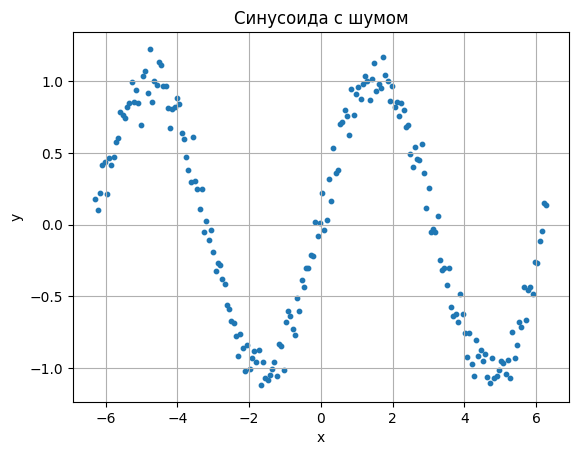

In [9]:
import matplotlib.pyplot as plt

np.random.seed(0)
X = np.linspace(-2*np.pi, 2*np.pi, 200)[:, None]  # (200,1)
y = np.sin(X) + 0.1*np.random.randn(*X.shape)     # шумные данные

plt.scatter(X, y, s=10)
plt.title("Синусоида с шумом")
plt.xlabel("x"); plt.ylabel("y"); plt.grid(True)
plt.show() 

In [3]:
class MLP:
    def __init__(self, layer_sizes, activation='tanh'):
        self.layer_sizes = layer_sizes
        self.activation = activation
        self.W, self.b = [], []
        self.Z_list, self.A_list = [], []
        self.dW_list, self.db_list = [], []
        for i in range(len(layer_sizes)-1):
            in_dim, out_dim = layer_sizes[i], layer_sizes[i+1]
            self.W.append(np.random.randn(in_dim, out_dim) * 0.1)
            self.b.append(np.zeros((1, out_dim)))

    def _activate(self, Z):
        if self.activation == 'sigmoid':
            return 1/(1+np.exp(-Z))
        elif self.activation == 'relu':
            return np.maximum(0, Z)
        elif self.activation == 'tanh':
            return np.tanh(Z)
        else:
            raise ValueError(self.activation)

    def _dactivate(self, Z):
        if self.activation == 'sigmoid':
            s = 1/(1+np.exp(-Z)); return s*(1-s)
        elif self.activation == 'relu':
            return (Z > 0).astype(float)
        elif self.activation == 'tanh':
            return 1 - np.tanh(Z)**2

    def forward(self, X):
        self.Z_list, self.A_list = [], []
        A = X; self.A_list.append(A)
        for i in range(len(self.W)):
            Z = A.dot(self.W[i]) + self.b[i]; self.Z_list.append(Z)
            A = self._activate(Z) if i < len(self.W)-1 else Z
            self.A_list.append(A)
        return A

    def mse(self, y_pred, y_true):
        return np.mean((y_pred - y_true)**2)

    def backward(self, y_true):
        m = y_true.shape[0]
        # выходной слой
        aL, zL = self.A_list[-1], self.Z_list[-1]
        delta = (2*(aL - y_true)/m)
        # градиенты выхода
        a_prev = self.A_list[-2]
        dW = a_prev.T.dot(delta)
        db = np.sum(delta, axis=0, keepdims=True)
        self.dW_list, self.db_list = [dW], [db]
        # скрытые
        for l in range(len(self.layer_sizes)-2, 0, -1):
            z = self.Z_list[l-1]
            a_prev = self.A_list[l-1]
            W_next = self.W[l]
            delta = delta.dot(W_next.T) * self._dactivate(z)
            dW = a_prev.T.dot(delta)
            db = np.sum(delta, axis=0, keepdims=True)
            self.dW_list.insert(0, dW)
            self.db_list.insert(0, db)

    def update_params(self, lr):
        # Обновляем веса и смещения
        for i in range(len(self.W)):
            # Обновляем веса W и смещения b.
            self.W[i] -= lr * self.dW_list[i]
            # Ваш код здесь
            self.b[i] -= lr * self.db_list[i]
            # Ваш код здесь


# Предполагается, что класс MLP уже определён (как в Задании 6)
# Инициализируйте сеть с параметрами 1-30-1 и активацией tanh

# Ваш код здесь
model = MLP([1, 30, 1], activation='tanh')

# Небольшая проверка
xx = np.random.randn(5, 1)
out = model.forward(xx)
print("out.shape =", out.shape) 

NameError: name 'np' is not defined

Epoch  50, loss=0.0951
Epoch 100, loss=0.0934
Epoch 150, loss=0.0918
Epoch 200, loss=0.0912
Epoch 250, loss=0.0891
Epoch 300, loss=0.0876


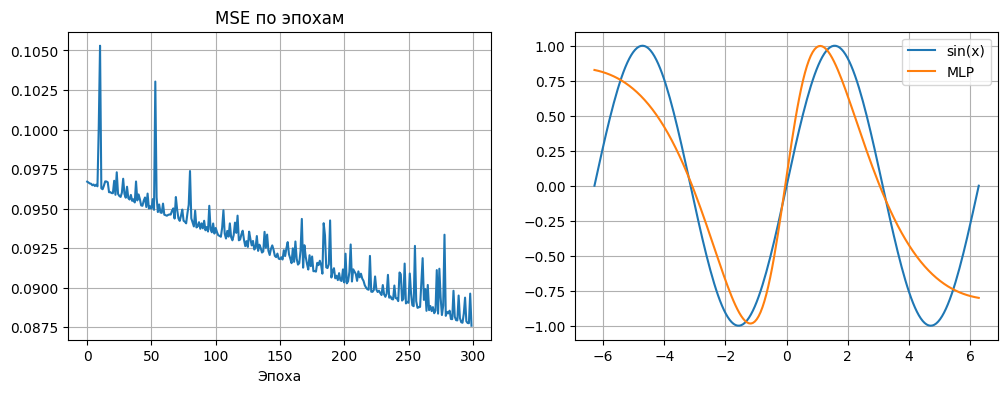

In [22]:
lr = 0.01
epochs = 300
batch_size = 30
loss_history = []

for epoch in range(1, epochs+1):
    perm = np.random.permutation(len(X))
    X_sh, y_sh = X[perm], y[perm]
    for start in range(0, len(X), batch_size):
        xb = X_sh[start:start+batch_size]
        yb = y_sh[start:start+batch_size]

        # Прямой проход
        preds = model.forward(xb)

        # Обратный проход
        model.backward(yb)

        # Обновление параметров
        model.update_params(lr)

    # Прямой проход на всех данных, нужен для вычисления потерь
    full_pred = model.forward(X)

    # Считаем потери на full_pred данных и добавляем в историю
    loss_history.append(model.mse(full_pred, y))
    
    # Выводим потери каждые 50 эпох
    if epoch % 50 == 0:
        print(f"Epoch {epoch:3d}, loss={loss_history[-1]:.4f}")

# Визуализация
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(loss_history); plt.title("MSE по эпохам"); plt.xlabel("Эпоха"); plt.grid(True)
plt.subplot(1,2,2)
xx = np.linspace(-2*np.pi, 2*np.pi, 200)[:, None]
plt.plot(xx, np.sin(xx), label="sin(x)")
plt.plot(xx, model.forward(xx), label="MLP")
plt.legend(); plt.grid(True)
plt.show()

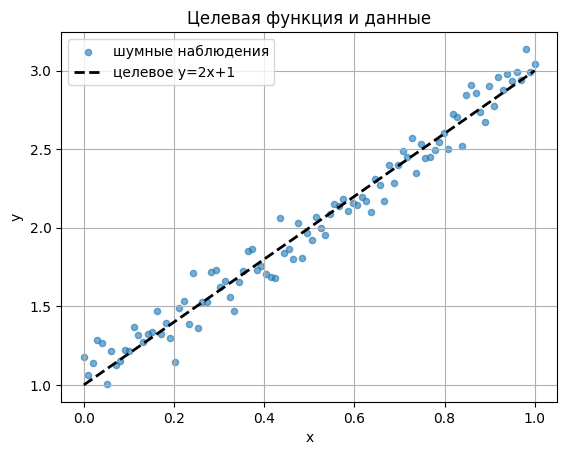

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Данные
np.random.seed(0)
X = np.linspace(0, 1, 100)[:, None]          # (100,1)
Y = 2 * X + 1 + np.random.randn(100,1)*0.1  # шумные точки

# Визуализация
plt.scatter(X, Y, s=20, alpha=0.6, label='шумные наблюдения')
# Чистая прямая y=2x+1
x_line = np.linspace(0,1,100)
plt.plot(x_line, 2*x_line+1, 'k--', linewidth=2, label='целевое y=2x+1')
plt.title("Целевая функция и данные")
plt.xlabel("x"); plt.ylabel("y")
plt.legend(); plt.grid(True)
plt.show()

Epoch  2: loss=2.3492, ||grad||=3.3817
Epoch  4: loss=0.7929, ||grad||=1.8880
Epoch  6: loss=0.3069, ||grad||=1.0587
Epoch  8: loss=0.1532, ||grad||=0.6013
Epoch 10: loss=0.1028, ||grad||=0.3538


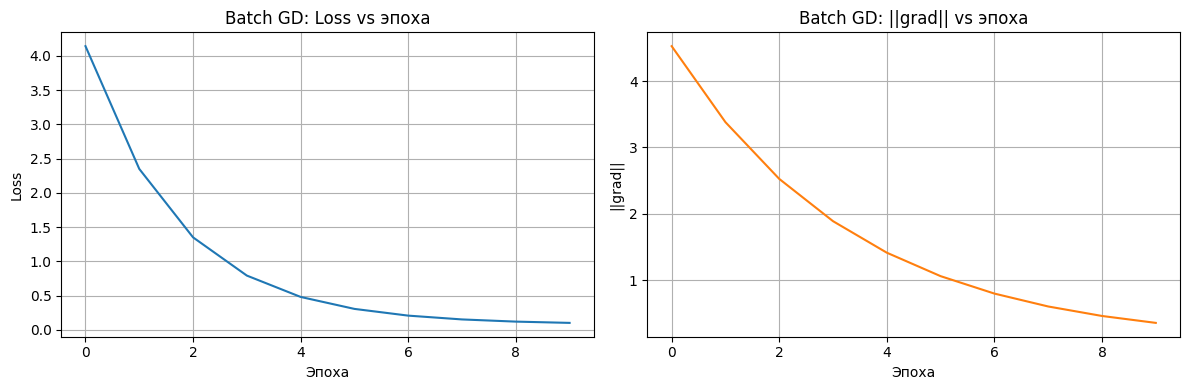

In [27]:
# Класс MLP был реализован в прошлых уроках

model = MLP([1, 1], activation='tanh')
lr, epochs = 0.1, 10

loss_history = []
grad_norms = []

for epoch in range(1, epochs + 1):
    preds = model.forward(X)
    loss = model.mse(preds, Y)
    loss_history.append(loss)

    model.backward(Y)

    # Соберите ВСЕ градиенты (dW и db) в один плоский вектор
    grads = np.concatenate(
        [g.ravel() for g in model.dW_list] +
        [g.ravel() for g in model.db_list])

    # 2. Вычислите евклидову норму вектора grads
    norm = np.linalg.norm(grads)
    grad_norms.append(norm)

    model.update_params(lr)

    if epoch % 2 == 0:
        print(f"Epoch {epoch:>2d}: loss={loss:.4f}, ||grad||={grad_norms[-1]:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(loss_history, color='tab:blue')
ax1.set(title="Batch GD: Loss vs эпоха", xlabel="Эпоха", ylabel="Loss")
ax1.grid(True)

ax2.plot(grad_norms, color='tab:orange')
ax2.set(title="Batch GD: ||grad|| vs эпоха", xlabel="Эпоха", ylabel="||grad||")
ax2.grid(True)

plt.tight_layout()
plt.show()

Epoch  1: loss=0.0854
Epoch  2: loss=0.0547
Epoch  3: loss=0.0356
Epoch  4: loss=0.0271
Epoch  5: loss=0.0189
Epoch  6: loss=0.0154
Epoch  7: loss=0.0132
Epoch  8: loss=0.0120
Epoch  9: loss=0.0112
Epoch 10: loss=0.0111


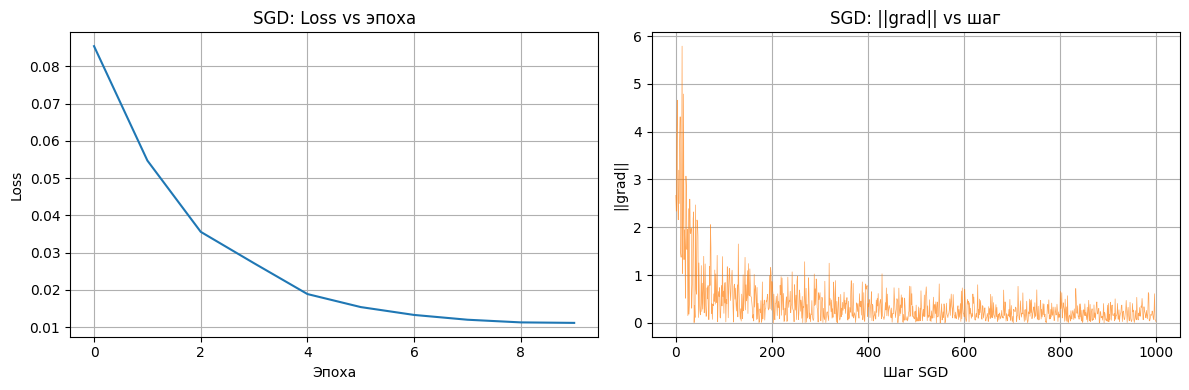

In [12]:
import numpy as np
import matplotlib.pyplot as plt

class MLP:
    def __init__(self, layer_sizes, activation='tanh'):
        self.layer_sizes = layer_sizes
        self.activation = activation
        self.W, self.b = [], []
        self.Z_list, self.A_list = [], []
        self.dW_list, self.db_list = [], []
        for i in range(len(layer_sizes)-1):
            in_dim, out_dim = layer_sizes[i], layer_sizes[i+1]
            self.W.append(np.random.randn(in_dim, out_dim) * 0.1)
            self.b.append(np.zeros((1, out_dim)))

    def _activate(self, Z):
        if self.activation == 'sigmoid':
            return 1/(1+np.exp(-Z))
        elif self.activation == 'relu':
            return np.maximum(0, Z)
        elif self.activation == 'tanh':
            return np.tanh(Z)
        else:
            raise ValueError(self.activation)

    def _dactivate(self, Z):
        if self.activation == 'sigmoid':
            s = 1/(1+np.exp(-Z)); return s*(1-s)
        elif self.activation == 'relu':
            return (Z > 0).astype(float)
        elif self.activation == 'tanh':
            return 1 - np.tanh(Z)**2

    def forward(self, X):
        self.Z_list, self.A_list = [], []
        A = X; self.A_list.append(A)
        for i in range(len(self.W)):
            Z = A.dot(self.W[i]) + self.b[i]; self.Z_list.append(Z)
            A = self._activate(Z) if i < len(self.W)-1 else Z
            self.A_list.append(A)
        return A

    def mse(self, y_pred, y_true):
        return np.mean((y_pred - y_true)**2)

    def backward(self, y_true):
        m = y_true.shape[0]
        # выходной слой
        aL, zL = self.A_list[-1], self.Z_list[-1]
        delta = (2*(aL - y_true)/m)
        # градиенты выхода
        a_prev = self.A_list[-2]
        dW = a_prev.T.dot(delta)
        db = np.sum(delta, axis=0, keepdims=True)
        self.dW_list, self.db_list = [dW], [db]
        # скрытые
        for l in range(len(self.layer_sizes)-2, 0, -1):
            z = self.Z_list[l-1]
            a_prev = self.A_list[l-1]
            W_next = self.W[l]
            delta = delta.dot(W_next.T) * self._dactivate(z)
            dW = a_prev.T.dot(delta)
            db = np.sum(delta, axis=0, keepdims=True)
            self.dW_list.insert(0, dW)
            self.db_list.insert(0, db)

    def update_params(self, lr):
        # Обновляем веса и смещения
        for i in range(len(self.W)):
            # Обновляем веса W и смещения b.
            self.W[i] -= lr * self.dW_list[i]
            # Ваш код здесь
            self.b[i] -= lr * self.db_list[i]
            # Ваш код здесь



model = MLP([1, 1], activation='tanh')
lr, epochs = 0.02, 10
np.random.seed(0)
X = np.linspace(0, 1, 100)[:, None]          # (100,1)
Y = 2 * X + 1 + np.random.randn(100,1)*0.1  # шумные точки

loss_history = []
grad_norms = []

for epoch in range(1, epochs + 1):
    # Перемешайте индексы от 0 до len(X)-1
    perm = np.random.permutation(len(X))
     

    for i in perm:
        xi, yi = X[i:i+1], Y[i:i+1]
        model.forward(xi)
        model.backward(yi)        

        # Сбор градиентов и нормы (уже знакомо из Задания 2)
        grads = np.concatenate(
            [g.ravel() for g in model.dW_list] +
            [g.ravel() for g in model.db_list]
        )
        grad_norms.append(np.linalg.norm(grads))
        model.update_params(lr)

    # Loss на всей выборке — считаем после каждой эпохи
    loss = model.mse(model.forward(X), Y)
    loss_history.append(loss)
    print(f"Epoch {epoch:>2d}: loss={loss:.4f}")


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(loss_history, color='tab:blue')
ax1.set(title="SGD: Loss vs эпоха", xlabel="Эпоха", ylabel="Loss")
ax1.grid(True)

ax2.plot(grad_norms, color='tab:orange', alpha=0.7, linewidth=0.5)
ax2.set(title="SGD: ||grad|| vs шаг", xlabel="Шаг SGD", ylabel="||grad||")
ax2.grid(True)

plt.tight_layout()
plt.show() 

Epoch  1: loss=0.3967
Epoch  2: loss=0.1195
Epoch  3: loss=0.0872
Epoch  4: loss=0.0764
Epoch  5: loss=0.0679
Epoch  6: loss=0.0605
Epoch  7: loss=0.0542
Epoch  8: loss=0.0486
Epoch  9: loss=0.0438
Epoch 10: loss=0.0397


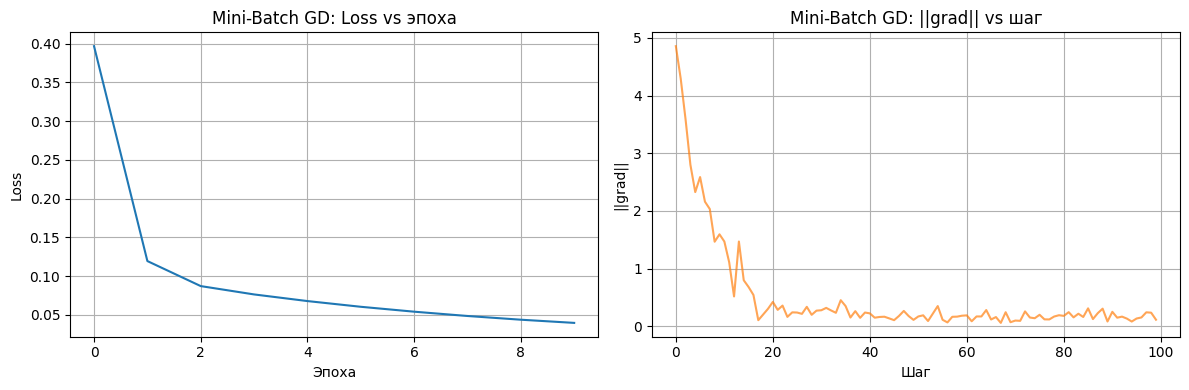

In [13]:
model = MLP([1, 1], activation='tanh')
lr = 0.05
epochs = 10
batch_size = 10

loss_history = []
grad_norms = []

for epoch in range(1, epochs + 1):
    perm = np.random.permutation(len(X))

    for start in range(0, len(X), batch_size):
        idxs = perm[start : start + batch_size]
        xb, yb = X[idxs], Y[idxs]

        # Прямой и обратный проход по батчу
        model.forward(xb)        
        model.backward(yb)

        # Соберите норму градиента (как в заданиях 2–3)
        grads = np.concatenate(
            [g.ravel() for g in model.dW_list] +
            [g.ravel() for g in model.db_list]
        )
        grad_norms.append(np.linalg.norm(grads))

        # Обновите параметры
        model.update_params(lr)

    # Loss после эпохи
    loss = model.mse(model.forward(X), Y)
    loss_history.append(loss)
    print(f"Epoch {epoch:>2d}: loss={loss:.4f}")

# --- Визуализация (ничего менять не нужно) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(loss_history, color='tab:blue')
ax1.set(title="Mini-Batch GD: Loss vs эпоха", xlabel="Эпоха", ylabel="Loss")
ax1.grid(True)

ax2.plot(grad_norms, color='tab:orange', alpha=0.7)
ax2.set(title="Mini-Batch GD: ||grad|| vs шаг", xlabel="Шаг", ylabel="||grad||")
ax2.grid(True)

plt.tight_layout()
plt.show() 

In [15]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
X = np.linspace(0, 1, 100)[:, None]          # (100,1)
Y = 2 * X + 1 + np.random.randn(100,1)*0.1  # шумные точки


class MLP:
    def __init__(self, layer_sizes, activation='tanh'):
        self.layer_sizes = layer_sizes
        self.activation = activation
        self.W, self.b = [], []
        self.Z_list, self.A_list = [], []
        self.dW_list, self.db_list = [], []
        for i in range(len(layer_sizes)-1):
            in_dim, out_dim = layer_sizes[i], layer_sizes[i+1]
            self.W.append(np.random.randn(in_dim, out_dim) * 0.1)
            self.b.append(np.zeros((1, out_dim)))

    def _activate(self, Z):
        if self.activation == 'sigmoid':
            return 1/(1+np.exp(-Z))
        elif self.activation == 'relu':
            return np.maximum(0, Z)
        elif self.activation == 'tanh':
            return np.tanh(Z)
        else:
            raise ValueError(self.activation)

    def _dactivate(self, Z):
        if self.activation == 'sigmoid':
            s = 1/(1+np.exp(-Z)); return s*(1-s)
        elif self.activation == 'relu':
            return (Z > 0).astype(float)
        elif self.activation == 'tanh':
            return 1 - np.tanh(Z)**2

    def forward(self, X):
        self.Z_list, self.A_list = [], []
        A = X; self.A_list.append(A)
        for i in range(len(self.W)):
            Z = A.dot(self.W[i]) + self.b[i]; self.Z_list.append(Z)
            A = self._activate(Z) if i < len(self.W)-1 else Z
            self.A_list.append(A)
        return A

    def mse(self, y_pred, y_true):
        return np.mean((y_pred - y_true)**2)

    def backward(self, y_true):
        m = y_true.shape[0]
        # выходной слой
        aL, zL = self.A_list[-1], self.Z_list[-1]
        delta = (2*(aL - y_true)/m)
        # градиенты выхода
        a_prev = self.A_list[-2]
        dW = a_prev.T.dot(delta)
        db = np.sum(delta, axis=0, keepdims=True)
        self.dW_list, self.db_list = [dW], [db]
        # скрытые
        for l in range(len(self.layer_sizes)-2, 0, -1):
            z = self.Z_list[l-1]
            a_prev = self.A_list[l-1]
            W_next = self.W[l]
            delta = delta.dot(W_next.T) * self._dactivate(z)
            dW = a_prev.T.dot(delta)
            db = np.sum(delta, axis=0, keepdims=True)
            self.dW_list.insert(0, dW)
            self.db_list.insert(0, db)

    def update_params(self, lr):
        # Обновляем веса и смещения
        for i in range(len(self.W)):
            # Обновляем веса W и смещения b.
            #  W[i] -= lr * dW_list[i]
            # Ваш код здесь
            #  b[i] -= lr * db_list[i]
            self.W[i] -= lr * self.dW_list[i]
            self.b[i] -= lr * self.db_list[i]


def mse(y, y_pred):
    return np.mean((y - y_pred) ** 2)

def mae(y, y_pred):
    return np.mean(np.abs(y - y_pred))

def huber(y, y_pred, delta=5):
    diff = y_pred - y_true
    small = np.abs(diff) <= delta
    sq = 0.5 * diff**2
    lin = delta * (np.abs(diff) - 0.5 * delta)
    return np.mean(np.where(small, sq, lin))

np.random.seed(0)
X = np.linspace(0, 1, 100)[:, None]
# Создаём линейную зависимость с шумом в виде np.random.randn(100,1)*0.1
Y = 2 * X + 1 + np.random.randn(100, 1) * 0.1


model = MLP([1,1], activation='tanh')
lr, epochs = 0.1, 50


# Истории для трёх loss
loss_mse, loss_mae, loss_huber = [], [], []

for epoch in range(1, epochs+1):
    preds = model.forward(X)

    # Считаем все три loss
    loss_mse.append(model.mse(preds, Y))
    loss_mae.append(np.mean(np.abs(preds - Y)))
    loss_huber.append(huber(preds, Y, delta=1.0))  # увеличили delta

    # Обучение
    model.backward(Y)
    model.update_params(lr)

# Визуализация
plt.figure(figsize=(8,5))
plt.plot(range(1, epochs+1), loss_mse, label='MSE')
plt.plot(range(1, epochs+1), loss_mae, label='MAE')
plt.plot(range(1, epochs+1), loss_huber, label='Huber (δ=1.0)')
plt.title("Снижение функций потерь по эпохам")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show() 

NameError: name 'y_true' is not defined

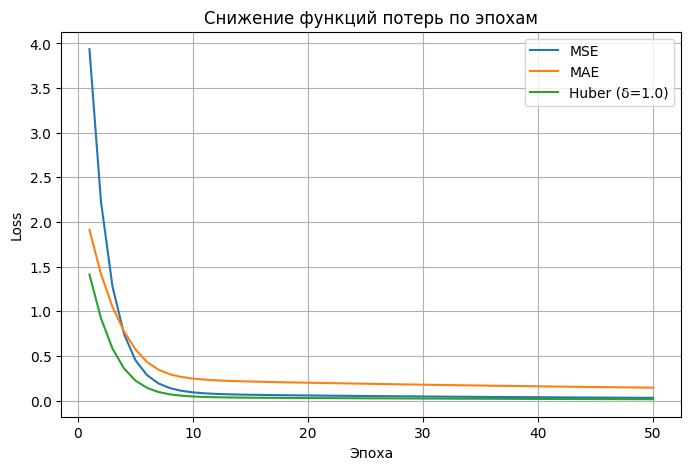

In [16]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
X = np.linspace(0, 1, 100)[:, None]          # (100,1)
Y = 2 * X + 1 + np.random.randn(100,1)*0.1  # шумные точки


class MLP:
    def __init__(self, layer_sizes, activation='tanh'):
        self.layer_sizes = layer_sizes
        self.activation = activation
        self.W, self.b = [], []
        self.Z_list, self.A_list = [], []
        self.dW_list, self.db_list = [], []
        for i in range(len(layer_sizes)-1):
            in_dim, out_dim = layer_sizes[i], layer_sizes[i+1]
            self.W.append(np.random.randn(in_dim, out_dim) * 0.1)
            self.b.append(np.zeros((1, out_dim)))

    def _activate(self, Z):
        if self.activation == 'sigmoid':
            return 1/(1+np.exp(-Z))
        elif self.activation == 'relu':
            return np.maximum(0, Z)
        elif self.activation == 'tanh':
            return np.tanh(Z)
        else:
            raise ValueError(self.activation)

    def _dactivate(self, Z):
        if self.activation == 'sigmoid':
            s = 1/(1+np.exp(-Z)); return s*(1-s)
        elif self.activation == 'relu':
            return (Z > 0).astype(float)
        elif self.activation == 'tanh':
            return 1 - np.tanh(Z)**2

    def forward(self, X):
        self.Z_list, self.A_list = [], []
        A = X; self.A_list.append(A)
        for i in range(len(self.W)):
            Z = A.dot(self.W[i]) + self.b[i]; self.Z_list.append(Z)
            A = self._activate(Z) if i < len(self.W)-1 else Z
            self.A_list.append(A)
        return A

    def mse(self, y_pred, y_true):
        return np.mean((y_pred - y_true)**2)

    def backward(self, y_true):
        m = y_true.shape[0]
        # выходной слой
        aL, zL = self.A_list[-1], self.Z_list[-1]
        delta = (2*(aL - y_true)/m)
        # градиенты выхода
        a_prev = self.A_list[-2]
        dW = a_prev.T.dot(delta)
        db = np.sum(delta, axis=0, keepdims=True)
        self.dW_list, self.db_list = [dW], [db]
        # скрытые
        for l in range(len(self.layer_sizes)-2, 0, -1):
            z = self.Z_list[l-1]
            a_prev = self.A_list[l-1]
            W_next = self.W[l]
            delta = delta.dot(W_next.T) * self._dactivate(z)
            dW = a_prev.T.dot(delta)
            db = np.sum(delta, axis=0, keepdims=True)
            self.dW_list.insert(0, dW)
            self.db_list.insert(0, db)

    def update_params(self, lr):
        # Обновляем веса и смещения
        for i in range(len(self.W)):
            # Обновляем веса W и смещения b.
            #  W[i] -= lr * dW_list[i]
            # Ваш код здесь
            #  b[i] -= lr * db_list[i]
            self.W[i] -= lr * self.dW_list[i]
            self.b[i] -= lr * self.db_list[i]

def mse(y, y_pred):
    return np.mean((y - y_pred)**2)

def mae(y, y_pred):
    return np.mean(np.abs(y - y_pred))

# Функция Huber с настраиваемым delta
def huber(y_pred, y_true, delta):
    diff = y_pred - y_true
    small = np.abs(diff) <= delta
    sq = 0.5 * diff**2
    lin = delta*(np.abs(diff) - 0.5*delta)
    return np.mean(np.where(small, sq, lin))

np.random.seed(0)
X = np.linspace(0, 1, 100)[:, None]
Y = 2 * X + 1 + np.random.randn(100,1)*0.1


model = MLP([1,1], activation='tanh')
lr, epochs = 0.1, 50

# Истории для трёх loss
loss_mse, loss_mae, loss_huber = [], [], []

for epoch in range(1, epochs+1):
    preds = model.forward(X)

    # Считаем все три loss
    loss_mse.append(model.mse(preds, Y))
    loss_mae.append(np.mean(np.abs(preds - Y)))
    loss_huber.append(huber(preds, Y, delta=1.0))  # увеличили delta

    # Обучение
    model.backward(Y)
    model.update_params(lr)

# Визуализация
plt.figure(figsize=(8,5))
plt.plot(range(1, epochs+1), loss_mse, label='MSE')
plt.plot(range(1, epochs+1), loss_mae, label='MAE')
plt.plot(range(1, epochs+1), loss_huber, label='Huber (δ=1.0)')
plt.title("Снижение функций потерь по эпохам")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(0)

class MLP:
    def __init__(self, layer_sizes, activation='tanh'):
        # Маленькая константа для избежания деления на ноль
        self.epsilon = 1e-8
        self.layer_sizes = layer_sizes
        self.activation = activation
        self.W, self.b = [], []
        self.Z_list, self.A_list = [], []
        self.dW_list, self.db_list = [], []
        # Добавим накопители квадратов градиентов
        self.GW, self.Gb = [], []


        for i in range(len(layer_sizes)-1):
            in_dim, out_dim = layer_sizes[i], layer_sizes[i+1]
            self.W.append(np.random.randn(in_dim, out_dim) * np.sqrt(2/(in_dim + out_dim)))
            self.b.append(np.zeros((1, out_dim)))
            # Инициализация накопителей нулями
            self.GW.append(0)
            self.Gb.append(0)


    def _activate(self, Z):
        if self.activation == 'sigmoid':
            return 1/(1+np.exp(-Z))
        elif self.activation == 'relu':
            return np.maximum(0, Z)
        elif self.activation == 'tanh':
            return np.tanh(Z)
        else:
            raise ValueError(self.activation)

    def _dactivate(self, Z):
        if self.activation == 'sigmoid':
            s = 1/(1+np.exp(-Z)); return s*(1-s)
        elif self.activation == 'relu':
            return (Z > 0).astype(float)
        elif self.activation == 'tanh':
            return 1 - np.tanh(Z)**2

    def forward(self, X):
        self.Z_list, self.A_list = [], []
        A = X; self.A_list.append(A)
        for i in range(len(self.W)):
            Z = A.dot(self.W[i]) + self.b[i]; self.Z_list.append(Z)
            A = self._activate(Z) if i < len(self.W)-1 else Z
            self.A_list.append(A)
        return A

    def mse(self, y_pred, y_true):
        return np.mean((y_pred - y_true)**2)

    def backward(self, y_true):
        m = y_true.shape[0]
        # Выходной слой (линейная активация, производная = 1)
        aL, zL = self.A_list[-1], self.Z_list[-1]
        delta = (2*(aL - y_true)/m)
        # Градиенты выхода
        a_prev = self.A_list[-2]
        dW = a_prev.T.dot(delta)
        db = np.sum(delta, axis=0, keepdims=True)
        self.dW_list, self.db_list = [dW], [db]
        # Скрытые слои (используем производную активации)
        for l in range(len(self.layer_sizes)-2, 0, -1):
            z = self.Z_list[l-1]
            a_prev = self.A_list[l-1]
            W_next = self.W[l]
            delta = delta.dot(W_next.T) * self._dactivate(z)
            dW = a_prev.T.dot(delta)
            db = np.sum(delta, axis=0, keepdims=True)
            self.dW_list.insert(0, dW)
            self.db_list.insert(0, db)


    def update_adagrad(self, lr):
        # Обновляем веса и смещения с помощью Adagrad
        for i in range(len(self.W)):
            self.GW[i] += self.dW_list[i] ** 2
            self.Gb[i] += self.db_list[i] ** 2

            adj_lr_w = lr / (np.sqrt(self.GW[i])) + self.epsilon
            adj_lr_b = lr / (np.sqrt(self.Gb[i])) + self.epsilon

            self.W[i] -= adj_lr_w * self.dW_list[i]
            self.b[i] -= adj_lr_b * self.db_list[i]

# Разбиваем на train/val
perm = np.random.permutation(len(X))
split = int(0.8 * len(X))
X_train, y_train = X[perm[:split]], y[perm[:split]]
X_val,   y_val   = X[perm[split:]], y[perm[split:]]

# Инициализация модели
mlp = MLP([1, 50, 1], activation='tanh')

# Параметры обучения и Reduce on Plateau
initial_lr = 0.01
lr = initial_lr
patience = 20
best_val_loss = np.inf
wait = 0
epochs = 2500

train_loss_history = []
val_loss_history   = []

for epoch in range(1, epochs+1):
    # тренировка на всём train
    preds_train = mlp.forward(X_train)
    train_loss = mlp.mse(preds_train, y_train)
    train_loss_history.append(train_loss)

    mlp.backward(y_train)
    mlp.update_adagrad(lr)

    # оценка на валидации
    preds_val = mlp.forward(X_val)
    val_loss = mlp.mse(preds_val, y_val)
    val_loss_history.append(val_loss)

    # Reduce on Plateau
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            lr *= 0.5
            wait = 0
            print(f"Epoch {epoch}: val_loss plateaued, new lr = {lr:.5f}")

    if epoch % 200 == 0:
        print(f"Epoch {epoch}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}, lr={lr:.5f}")

# График финальной аппроксимации
preds_all = mlp.forward(X)
idx = np.argsort(X.flatten())
plt.figure(figsize=(6,4))
plt.scatter(X, y, s=10, alpha=0.5, label='Данные')
plt.plot(X.flatten()[idx], preds_all.flatten()[idx],
         color='red', linewidth=2, label='MLP AdaGrad Approximation')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Аппроксимация sin(x)')
plt.legend()
plt.grid(True)
plt.show()

NameError: name 'X' is not defined